In [301]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import torch
import os
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer, utils
from transformers import AutoTokenizer
from dictionary_learning.mask_scae import SCAESuite, MergedSCAESuite # Your SCAESuite class
from datasets import load_dataset
from dictionary_learning.buffer import chunk_and_tokenize
from interp.interp_utils_new import (
    load_tokenized_dataset,
    collect_activations_and_tokens,
    generate_feature_dashboard,
    plot_alive_feature_percentage
)

torch.set_grad_enabled(False)

# --- Configuration ---
MODEL_NAME = "EleutherAI/pythia-70m"
PATH_TO_PILE = "/root/dictionary_learning/pile-uncopyrighted"
# For local pile, you might need to specify data_files if it's a collection of .jsonl.gz
# e.g., data_files = {"train": ["/path/to/pile/train/00.jsonl.gz", ...]}
# For HF streaming, data_files can be None.
DATA_FILES = None # Set to list of local file paths if using local pile and not streaming
STREAM_PILE = True # If True, streams from HF. If False and DATA_FILES is None, loads non-streamed from HF.
                   # If DATA_FILES is set, STREAM_PILE=True will stream from those local files.
SEQ_LEN = 128
NUM_SAMPLES_TO_LOAD = 5000 # How many sequences to prepare from the dataset
NUM_SAMPLES_TO_PROCESS = 5000 # How many sequences to run through the suite for activations (max_batches_to_process * batch_size)
BATCH_SIZE_COLLECT = 64
OUTPUT_ACTIVATIONS_DIR = "output_activations_pile"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Dashboards

In [2]:
# # --- Initialize Model and Tokenizer ---
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE, dtype=torch.bfloat16)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer = utils.get_tokenizer_with_bos(tokenizer)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

suite = SCAESuite.from_pretrained(
    repo_id="jacobcd52/pythia-70m_warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005",
    model=model,
    device=DEVICE,
    dtype=torch.bfloat16
)

print(f"Using device: {DEVICE}")
os.makedirs(OUTPUT_ACTIVATIONS_DIR, exist_ok=True)

Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Using device: cuda


In [4]:
raw_dataset = load_dataset(
    PATH_TO_PILE,
    split=f"train[:1%]",
).shuffle(seed=42)

tokenized_dataset = chunk_and_tokenize(
    dataset=raw_dataset,
    tokenizer=tokenizer,
    text_key="text",
    max_length=SEQ_LEN,
    num_proc=max(1, os.cpu_count() // 2),
    load_from_cache_file=True
)

if len(tokenized_dataset) > NUM_SAMPLES_TO_PROCESS:
    dataset_to_process = tokenized_dataset.select(range(NUM_SAMPLES_TO_PROCESS))
else:
    dataset_to_process = tokenized_dataset

Filter (num_proc=48): 100%|██████████| 58992/58992 [00:00<00:00, 98382.29 examples/s] 


In [5]:
toks_list = []
iterable_dataset = iter(dataset_to_process)
for _ in range(512):
    toks_list.append(next(iterable_dataset)['input_ids'])
toks = torch.stack(toks_list[:256], dim=0)
toks_test = torch.stack(toks_list[256:], dim=0)


layer = 3
ae = suite.module_dict[f'attn_{layer}'].ae
hook_pt = f'blocks.{layer}.hook_attn_out'
_, cache = model.run_with_cache(toks, return_type="loss", names_filter=[hook_pt])
act = cache[hook_pt]
f = ae.encode(act)
recons = ae.decode(f)
fvu = (act - recons).pow(2).sum() / (act - act.mean(dim=[0, 1])).pow(2).sum()

print("SAE FVU: ", fvu)

_, cache_test = model.run_with_cache(toks_test, return_type="loss", names_filter=[hook_pt])
act_test = cache_test[hook_pt]

# Compute PCA on training activations
q = 16
U, S, V = torch.pca_lowrank(act.float().reshape(-1, act.shape[-1]), q=q)
V = V.to(act.dtype)
# Project test activations onto PCA components
act_test_flat = act_test.reshape(-1, act_test.shape[-1])
act_test_proj = act_test_flat @ V
# Compute variance explained
total_var = (act_test_flat - act_test_flat.mean(dim=[0, 1])).pow(2).sum()
explained_var = (act_test_proj - act_test_proj.mean(dim=[0, 1])).pow(2).sum()
print(f"FVU of top {q} PCA components: {1 - explained_var/total_var:.3f}")

SAE FVU:  tensor(0.2500, device='cuda:0', dtype=torch.bfloat16)
FVU of top 16 PCA components: 0.484


In [6]:
# --- Collect Activations ---
# Determine the number of batches to process
max_batches = NUM_SAMPLES_TO_PROCESS // BATCH_SIZE_COLLECT

# Collect for sparse_false mode
print("Starting activation collection for sparse_false mode...")
collect_activations_and_tokens(
    suite=suite,
    model=model,
    tokenizer=tokenizer,
    dataset=dataset_to_process,
    device=DEVICE,
    output_dir=OUTPUT_ACTIVATIONS_DIR,
    run_mode_sparse=False,
    batch_size=BATCH_SIZE_COLLECT,
    max_batches_to_process=max_batches
)
print("Finished activation collection for sparse_false mode.")

# Collect for sparse_true mode
print("\\nStarting activation collection for sparse_true mode...")
collect_activations_and_tokens(
    suite=suite,
    model=model,
    tokenizer=tokenizer,
    dataset=dataset_to_process,
    device=DEVICE,
    output_dir=OUTPUT_ACTIVATIONS_DIR,
    run_mode_sparse=True,
    batch_size=BATCH_SIZE_COLLECT,
    max_batches_to_process=max_batches
)
print("Finished activation collection for sparse_true mode.")

Starting activation collection for sparse_false mode...
Starting activation collection. Mode: Non-sparse
Saving to: output_activations_pile/sparse_false
Processed and saved batch 0
Processed and saved batch 10
Processed and saved batch 20
Processed and saved batch 30
Processed and saved batch 40
Processed and saved batch 50
Processed and saved batch 60
Processed and saved batch 70
Reached max_batches_to_process: 78. Stopping.
Finished activation collection for mode: Non-sparse.
Finished activation collection for sparse_false mode.
\nStarting activation collection for sparse_true mode...
Starting activation collection. Mode: Sparse
Saving to: output_activations_pile/sparse_true
Processed and saved batch 0
Processed and saved batch 10
Processed and saved batch 20
Processed and saved batch 30
Processed and saved batch 40
Processed and saved batch 50
Processed and saved batch 60
Processed and saved batch 70
Reached max_batches_to_process: 78. Stopping.
Finished activation collection for mo

In [81]:
import pprint
from interp.interp_utils_new import find_non_dead_features

activations_directory = OUTPUT_ACTIVATIONS_DIR

# --- Find and Display Non-Dead Features ---
print(f"Searching for non-dead features in: {activations_directory}\n")

non_dead_feature_lists = find_non_dead_features(activations_directory)

print("\n--- Results ---")
for mode, modules in non_dead_feature_lists.items():
    print(f"\nMode: '{mode}'")
    if not modules:
        print("  No non-dead features found.")
        continue
    
    total_non_dead = 0
    for module_name, feature_indices in modules.items():
        count = len(feature_indices)
        total_non_dead += count
        print(f"  - Module: {module_name:<10} | Non-dead features: {count}")
    
    print(f"  Total non-dead features in this mode: {total_non_dead}")

# For a more detailed look at the full lists:
# print("\n--- Detailed Lists ---")
# pprint.pprint(non_dead_feature_lists)

Searching for non-dead features in: output_activations_pile

Processing mode: sparse_true...
Processing mode: sparse_false...
Finished finding non-dead features.

--- Results ---

Mode: 'sparse_true'
  - Module: attn_0     | Non-dead features: 604
  - Module: cc_0       | Non-dead features: 1261
  - Module: attn_1     | Non-dead features: 288
  - Module: cc_1       | Non-dead features: 1420
  - Module: attn_2     | Non-dead features: 1879
  - Module: cc_2       | Non-dead features: 780
  - Module: attn_3     | Non-dead features: 601
  - Module: cc_3       | Non-dead features: 284
  - Module: attn_4     | Non-dead features: 107
  - Module: cc_4       | Non-dead features: 382
  - Module: attn_5     | Non-dead features: 41
  - Module: cc_5       | Non-dead features: 16
  Total non-dead features in this mode: 7663

Mode: 'sparse_false'
  - Module: attn_0     | Non-dead features: 604
  - Module: cc_0       | Non-dead features: 1261
  - Module: attn_1     | Non-dead features: 1011
  - Module

In [204]:
non_dead_feature_lists['sparse_true']['cc_3'][:16]

[7, 17, 21, 24, 28, 38, 40, 45, 51, 90, 104, 108, 113, 115, 120, 162]

In [298]:
# --- Generate Feature Dashboard ---
# Choose which activations to analyze (sparse or non-sparse)
mode_to_analyze = "sparse_true" 
activations_path = os.path.join(OUTPUT_ACTIVATIONS_DIR, mode_to_analyze)
module_to_inspect = "cc_3"
feature_idx_in_module = 162

# Check if the activations path for the chosen mode exists
if not os.path.exists(activations_path):
    print(f"Activations path {activations_path} does not exist. Run collection for this mode first.")
else:
    # Check if there are any batch folders in the activations_path
    batch_folders_exist = any(d.startswith("batch_") for d in os.listdir(activations_path))
    if not batch_folders_exist:
        print(f"No batch data found in {activations_path}. Ensure activation collection was successful.")
    else:
        print(f"Generating dashboard using activations from: {activations_path}")
        generate_feature_dashboard(
            module_name_str=module_to_inspect,
            feature_idx_in_module=feature_idx_in_module,
            activations_base_dir=activations_path,
            tokenizer=tokenizer,
            model=model,
            suite=suite,
            k_top_contexts=20,
            k_top_connections=5,
            context_window_size=256 # Number of tokens around the max activating one
        )

Generating dashboard using activations from: output_activations_pile/sparse_true
Generating dashboard for: cc_3, Feature Index: 162


In [ ]:
layer = 3
dec = suite.module_dict[f'cc_{layer}'].ae.decoder_weight.sum(1)
u = model.W_U
logits = dec @ u
dec.shape, u.shape, logits.shape

(torch.Size([4096, 512]), torch.Size([512, 50304]), torch.Size([4096, 50304]))

In [277]:
vals, inds = logits[162].topk(20)
for v, i in zip(vals, inds):
    print(f"{v:.2f}: {tokenizer.decode(i)}")

2.62: ulate
2.58: clerotic
2.55: emb
2.55: ail
2.42: istration
2.41: itary
2.41: ies
2.31: ======
2.30:  prompted
2.27: ov
2.25: ails
2.23: contains
2.23: ulates
2.23: >::
2.22: Images
2.17: ians
2.16: abad
2.14:  promotion
2.14: were
2.11: iverse


# Plots

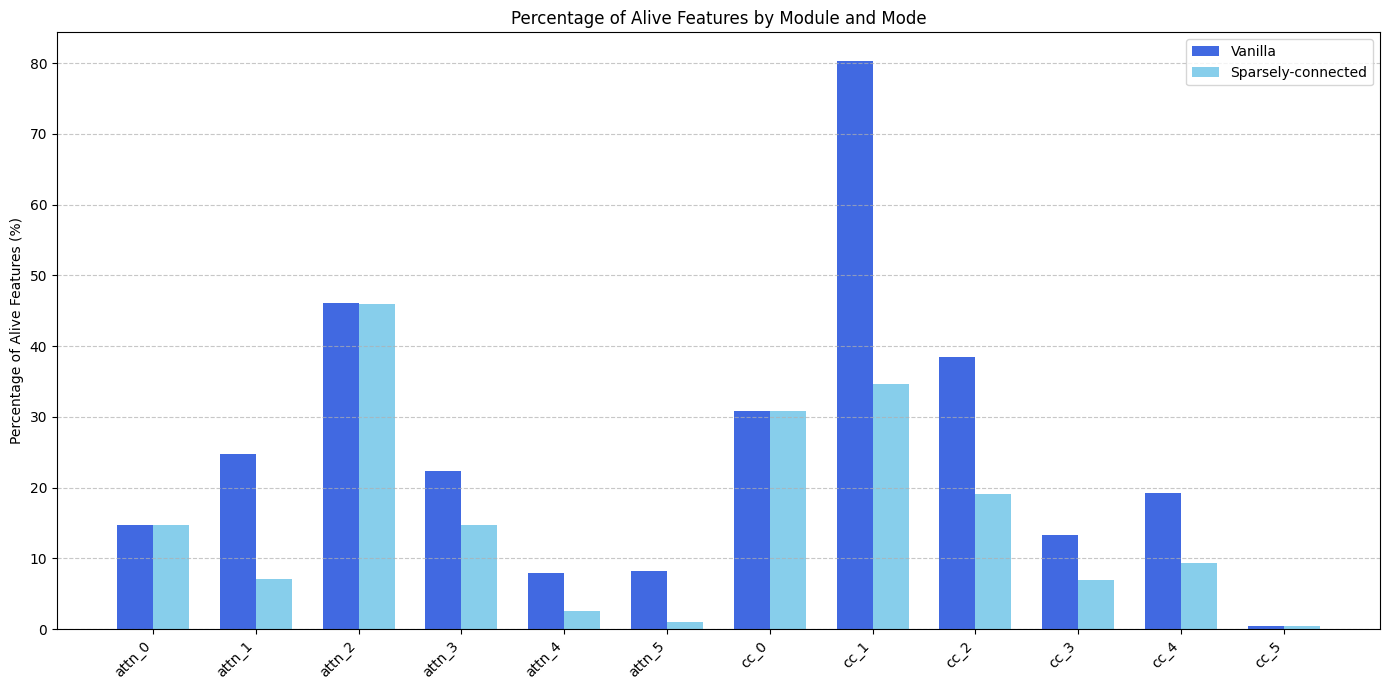

In [315]:
plot_alive_feature_percentage(non_dead_feature_lists, suite)

Generating upstream connection histograms for mode: sparse_true


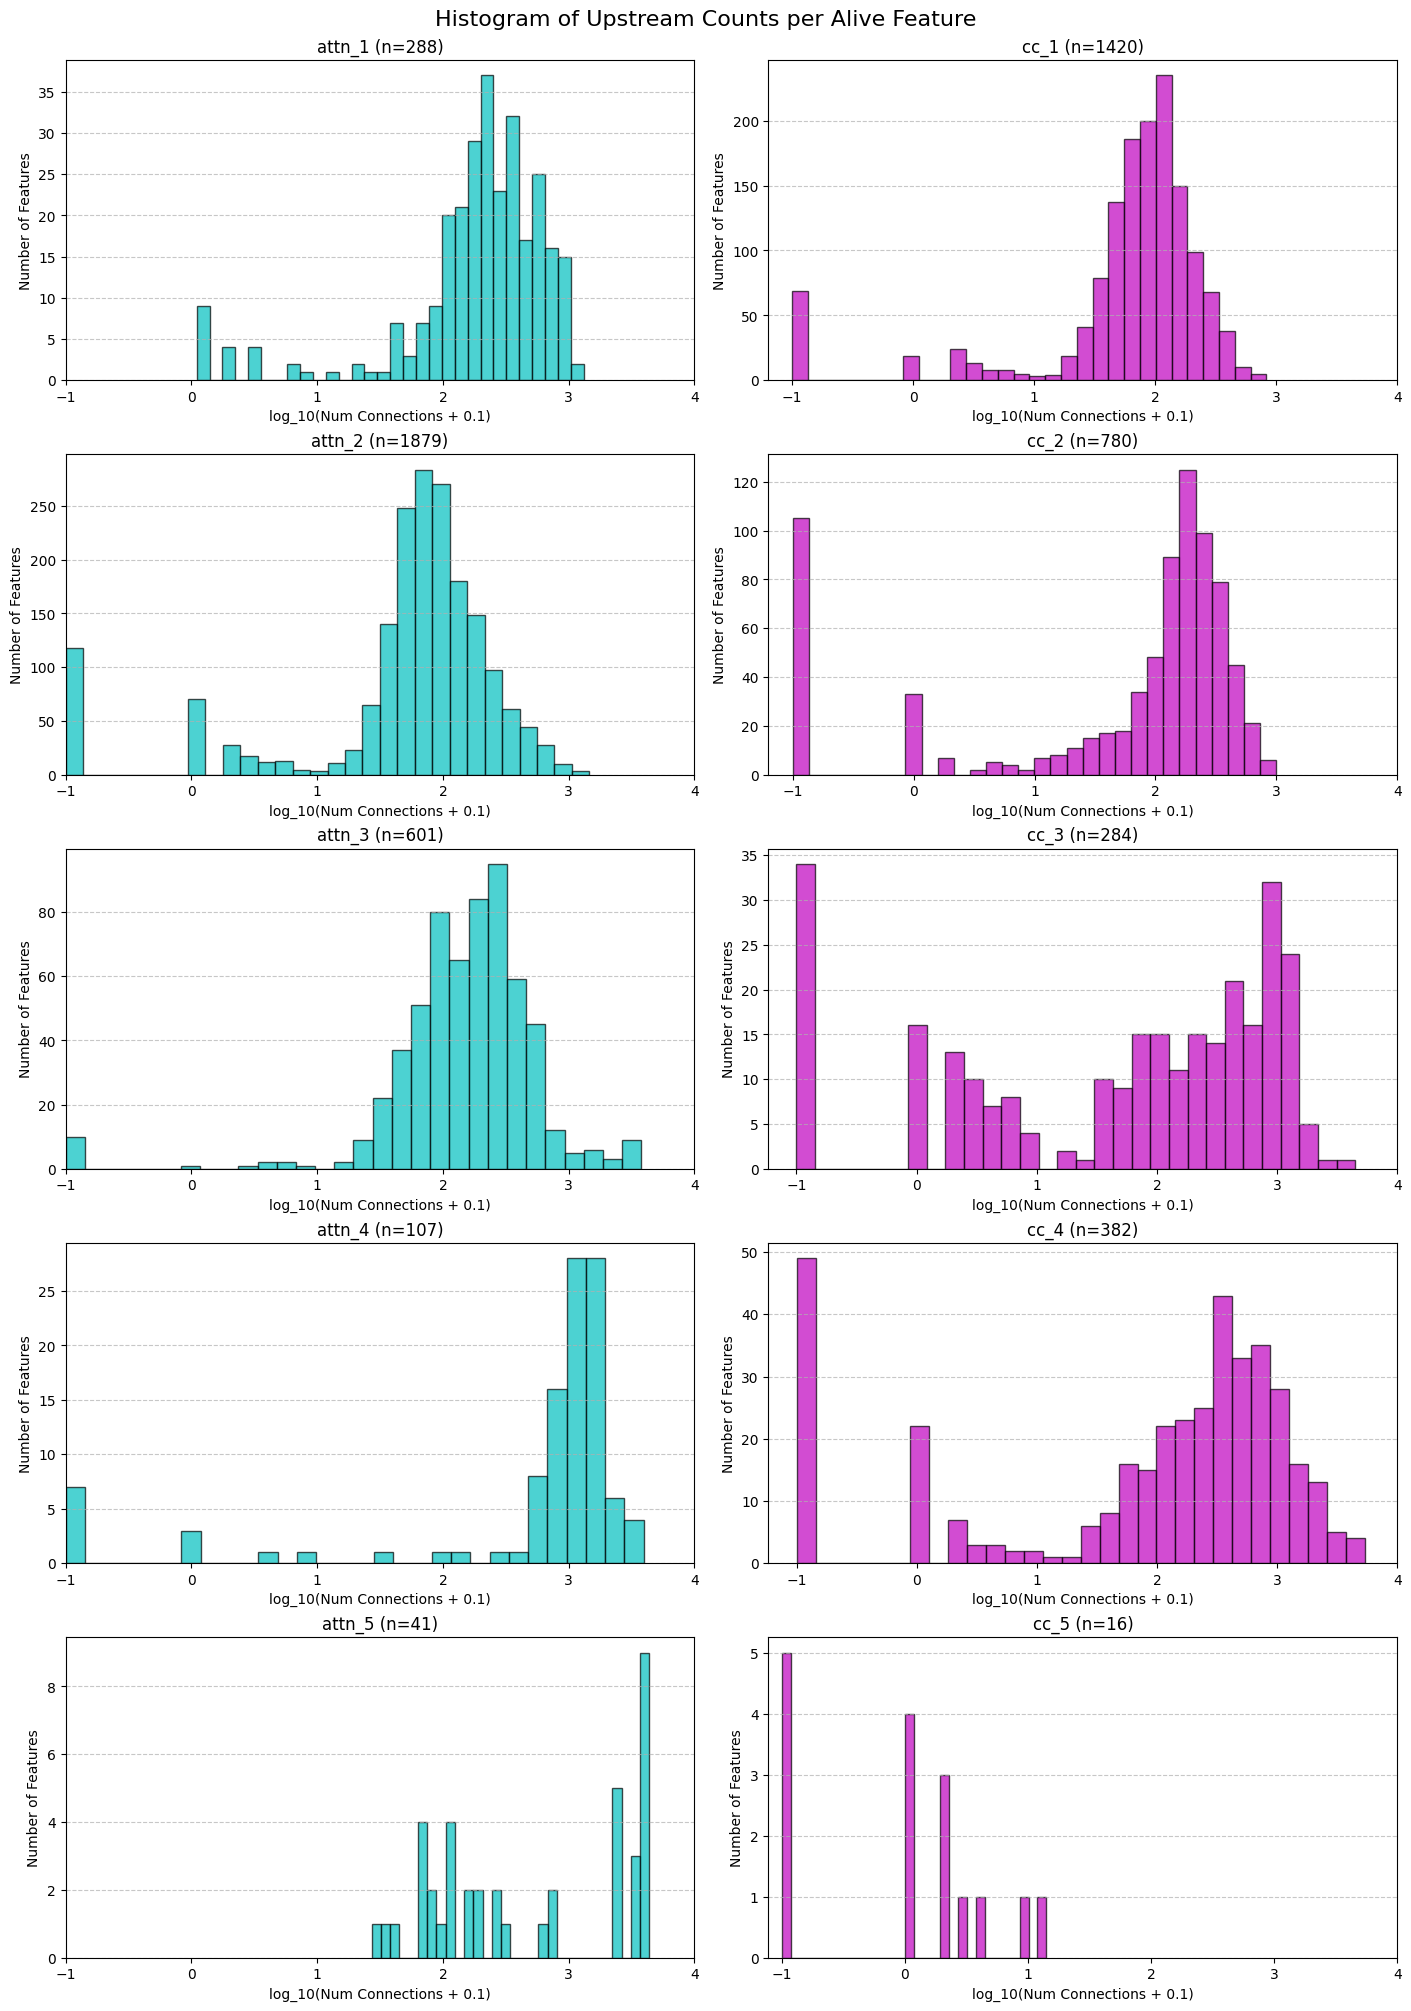

In [319]:
from interp.interp_utils_new import plot_upstream_connection_histograms

plot_upstream_connection_histograms(suite, non_dead_feature_lists)

TODO:

- save is_alive for each suite

In [321]:
from interp.interp_utils_new import calculate_global_connection_stats
mean_val, median_val = calculate_global_connection_stats(suite, non_dead_feature_lists)

Calculating global connection stats for mode: sparse_true...

--- Global Connection Statistics ---
Total alive features analyzed (from modules > layer 0): 5798
Mean upstream connections per feature: 215.74
Median upstream connections per feature: 100.00


In [ ]:
toks_list = []
iterable_dataset = iter(dataset_to_process)
for _ in range(512):
    toks_list.append(next(iterable_dataset)['input_ids'])
toks = torch.stack(toks_list, dim=0)


layer = 3
ae = suite.module_dict[f'attn_{layer}'].ae
hook_pt = f'blocks.{layer}.hook_attn_out'
_, cache = model.run_with_cache(toks, return_type="loss", names_filter=[hook_pt])
act = cache[hook_pt]
f = ae.encode(act)
recons = ae.decode(f)
fvu = (act - recons).pow(2).sum() / (act - act.mean(dim=[0, 1])).pow(2).sum()

print("SAE FVU: ", fvu)

In [303]:
merged_suite = MergedSCAESuite(model, suite)

In [307]:
reconstructions, _, cache = merged_suite.forward(toks, temperature=0.0, runtime_use_sparse_connections_override=True)

In [314]:
reconstructions['cc_3'].shape

torch.Size([256, 128, 3, 512])

In [1]:
import wandb
api = wandb.Api()

run_names = [
    "ux14r2wq",
    "2nzm8aww",
    "9tlyf1bm",
    "7f6i9wrq",
    "fsrl695z",
    "wrk57krc",
    "oakj0wkr"
]
run = api.run("training-saes/pythia_scae_cc_sweep/ux14r2wq")

In [16]:
run.history()[-10:]

,non_sparse_fvu_contrib/attn_attn_1,_runtime,C/attn_2,sparse_fvu_contrib/mlp_1,feature_act_fvu_contrib/cc_0,mask_loss_module/attn_4,non_sparse_fvu_contrib/attn_attn_0,C/attn_5,non_sparse_fvu_contrib/mlp_4,train/feature_act_fvu_unscaled,...,train/total_mask_loss_unscaled,C/attn_1,dead_pct/attn_2,non_sparse_fvu/total_fvu,dead_pct/attn_3,sparse_fvu_contrib/mlp_3,non_sparse_fvu_contrib/attn_attn_2,dead_pct/cc_2,sparse_fvu_contrib/attn_attn_2,mask_loss_module/cc_5
490,0.251953,33557.400471,16384,0.312500,0,17280,0.166992,40960,0.117676,2.765625,...,129408,8192,0.490723,2.656250,0.781982,0.386719,0.203125,0.425537,0.343750,21632
491,0.261719,33637.802887,16384,0.314453,0,17280,0.169922,40960,0.122559,2.812500,...,129408,8192,0.490723,2.671875,0.786621,0.396484,0.204102,0.428223,0.351562,21632
492,0.263672,33759.810376,16384,0.320312,0,17280,0.167969,40960,0.125000,2.890625,...,129408,8192,0.489990,2.781250,0.786621,0.394531,0.209961,0.427002,0.353516,21632
493,0.251953,33782.028700,16384,0.314453,0,17280,0.165039,40960,0.121094,2.703125,...,129408,8192,0.489990,2.671875,0.784424,0.384766,0.205078,0.428711,0.349609,21632
494,0.250000,33793.119683,16384,0.312500,0,17280,0.165039,40960,0.116211,2.703125,...,129408,8192,0.490479,2.625000,0.784424,0.384766,0.203125,0.428955,0.347656,21632
495,0.253906,33801.412126,16384,0.316406,0,17280,0.166016,40960,0.123535,2.734375,...,129408,8192,0.489990,2.687500,0.784424,0.390625,0.206055,0.427734,0.347656,21632
496,0.259766,33854.174618,16384,0.324219,0,17280,0.168945,40960,0.123535,2.812500,...,129408,8192,0.489990,2.687500,0.785156,0.398438,0.207031,0.429199,0.353516,21632
497,0.257812,33920.732995,16384,0.318359,0,17280,0.166016,40960,0.121094,2.718750,...,129408,8192,0.490234,2.781250,0.784180,0.386719,0.208008,0.427734,0.347656,21632
498,0.251953,33942.957656,16384,0.312500,0,17280,0.165039,40960,0.119141,2.687500,...,129408,8192,0.489746,2.718750,0.783936,0.382812,0.203125,0.427734,0.339844,21632
499,0.251953,34012.269695,16384,0.312500,0,17280,0.166016,40960,0.121094,2.750000,...,129408,8192,0.495605,2.734375,0.786621,0.390625,0.204102,0.428955,0.345703,21632


In [33]:
from tqdm import tqdm

def get_fvu(run_name, last_n=5):
    api = wandb.Api()
    run = api.run(f"training-saes/pythia_scae_cc_sweep/{run_name}")
    data = run.history()

    sparse_fvu = {}
    non_sparse_fvu = {}

    for layer in range(6):
        for module in ["mlp", "attn_attn"]:
            module_name = f"{module}_{layer}"
            sparse_fvu[module_name] = []
            for i in range(10):
                sparse_fvu[module_name] = sum(data[f"sparse_fvu_contrib/{module_name}"][-last_n:])/last_n
                non_sparse_fvu[module_name] = sum(data[f"non_sparse_fvu_contrib/{module_name}"][-last_n:])/last_n

    return sparse_fvu, non_sparse_fvu
        

In [34]:
sparse_fvu, non_sparse_fvu = get_fvu("ux14r2wq")

In [36]:
non_sparse_fvu

{'mlp_0': 0.236328125,
 'attn_attn_0': 0.166015625,
 'mlp_1': 0.237890625,
 'attn_attn_1': 0.255859375,
 'mlp_2': 0.044140625,
 'attn_attn_2': 0.20625,
 'mlp_3': 0.2037109375,
 'attn_attn_3': 0.226171875,
 'mlp_4': 0.120703125,
 'attn_attn_4': 0.534375,
 'mlp_5': 0.0880859375,
 'attn_attn_5': 0.426953125}